# OCR Pipeline

This notebook demonstrates the complete license plate recognition pipeline

In [2]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import easyocr

from ultralytics import YOLO

from py_files.detection import extract_plate
from py_files.preprocessing import preprocess_plate
from py_files.ocr import recognize_plate

In [3]:
# Load models

model = YOLO("../models/best.pt")

reader = easyocr.Reader(
    ["en"],
    gpu=False
)

Using CPU. Note: This module is much faster with a GPU.


In [4]:
image_path = "../data/oekraine32.jpg"

In [5]:
plates = extract_plate(
    image_path,
    model
)

print(f"Detected plates: {len(plates)}")

if len(plates) == 0:
    raise ValueError("No license plate detected.")

plate = plates[0]

Detected plates: 1


In [6]:
from py_files.postprocessing import best_prediction

In [7]:
result = best_prediction(
    plate,
    reader
)

C:\Users\User\PycharmProjects\JupyterProject\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [8]:
comparison = pd.DataFrame(
    result["predictions"]
)

comparison

,text,confidence,method
0,UACA3232CK,0.982652,otsu
1,UACA3232CK,0.972699,baseline
2,CA3232CK,0.950252,clahe_otsu
3,UACA3232CK,0.897241,equalize
4,UACA3232CK,0.857253,clahe
5,UA4E,0.572536,adaptive


In [9]:
print("Raw OCR:")
print(result["raw_prediction"])

print()

print("Final OCR:")
print(result["prediction"])

print()

print("Confidence:")
print(result["confidence"])

print()

print("Best preprocessing:")
print(result["best_method"])

Raw OCR:
UACA3232CK

Final OCR:
UACA3232CK

Confidence:
0.9826515513794796

Best preprocessing:
otsu


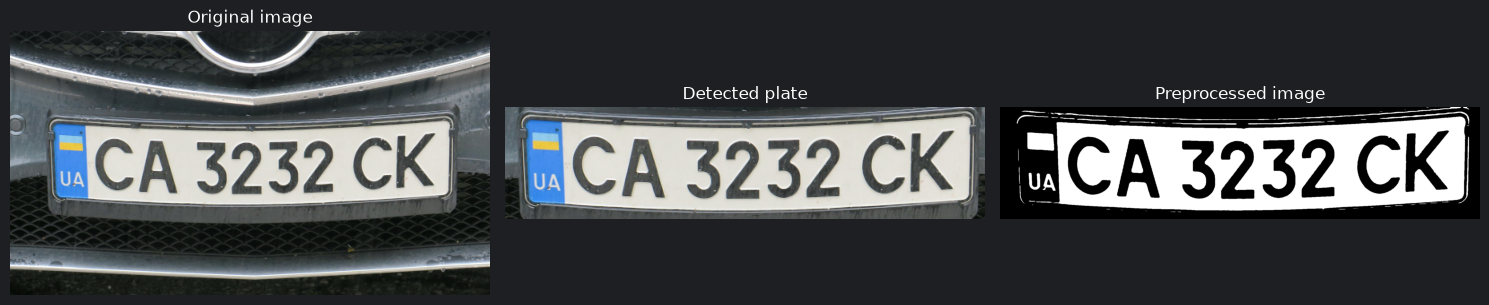

In [10]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(15,5)
)
original = cv2.imread(image_path)
original = cv2.cvtColor(
    original,
    cv2.COLOR_BGR2RGB
)
processed = preprocess_plate(
    plate,
    method=result["best_method"],
    use_super_resolution=True
)

ax[0].imshow(original)
ax[0].set_title("Original image")

ax[1].imshow(plate)
ax[1].set_title("Detected plate")

ax[2].imshow(
    processed,
    cmap="gray"
)
ax[2].set_title("Preprocessed image")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()